<a href="https://colab.research.google.com/github/AI-Engineer-Abhi/Junior-AI-Engineer---Training/blob/main/Task-Day5/Assignment(Python_Lib).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

AI Model Health Monitoring & Failure Risk Prediction

Objective

You are working as an AI Engineer in an organization that has deployed multiple
Machine Learning and Deep Learning models into production.
The company wants to proactively identify AI models that are at risk of failure before
deployment due to issues such as high latency, data drift, low prediction confidence, or
excessive resource utilization.

Your task is to analyze the dataset, visualize insights, build an AI model, evaluate its
performance, and provide business recommendations.

In [54]:
# Dataset

data = {
"ModelID": [
"M001","M002","M003","M004","M005","M006","M007","M008","M009","M010",
"M011","M012","M013","M014","M015","M016","M017","M018","M019","M020",
"M021","M022","M023","M024","M025","M026","M027","M028","M029","M030",
"M031","M032","M033","M034","M035","M036","M037","M038","M039","M040",
        "M041","M042","M043","M044","M045","M046","M047","M048","M049","M050"
    ],

    "Algorithm": [
        "RandomForest","XGBoost","CNN","LSTM","SVM",
        "DecisionTree","Transformer","RandomForest","CNN","XGBoost",
        "LSTM","Transformer","SVM","RandomForest","CNN",
        "XGBoost","DecisionTree","LSTM","Transformer","CNN",
        "RandomForest","XGBoost","CNN","Transformer","SVM",
        "DecisionTree","RandomForest","CNN","LSTM","Transformer",
        "RandomForest","CNN","XGBoost","LSTM","SVM",
        "Transformer","DecisionTree","RandomForest","CNN","XGBoost",
        "LSTM","Transformer","CNN","RandomForest","SVM",
        "DecisionTree","XGBoost","Transformer","CNN","RandomForest"
    ],

    "TrainingSamples": [
        120000,95000,150000,210000,85000,
        60000,300000,140000,175000,98000,
        225000,315000,90000,132000,182000,
        110000,72000,250000,330000,165000,
        128000,103000,194000,280000,88000,
        64000,145000,180000,240000,350000,
        150000,190000,100000,260000,92000,
        340000,70000,155000,205000,115000,
        270000,360000,170000,149000,87000,
        62000,108000,320000,185000,142000
    ],

    "Accuracy": [
        96.2,91.5,98.1,94.6,88.2,
        84.5,99.1,95.8,97.3,90.8,
        95.2,99.4,89.3,94.8,96.7,
        92.4,83.9,95.9,99.5,97.0,
        95.1,91.2,97.8,99.0,87.6,
        84.2,95.7,97.5,96.0,99.2,
        95.5,97.2,91.0,95.8,88.5,
        99.1,83.7,95.6,97.4,92.1,
        95.9,99.6,96.8,94.9,88.8,
        84.0,91.8,99.3,97.1,95.3
    ],

    "InferenceLatency": [
        45,80,120,95,40,
        30,210,55,130,85,
        110,260,42,60,125,
        78,28,108,240,135,
        58,82,118,225,38,
        25,52,132,105,250,
        63,128,76,115,41,
        235,26,50,138,74,
        112,255,127,57,39,
        27,79,220,129,56
    ],

    "DataDrift": [
        2,8,3,6,18,
        25,1,4,5,10,
        7,0,20,6,3,
        9,27,5,1,4,
        6,8,2,1,19,
        26,5,4,6,0,
        3,2,9,5,18,
        1,28,4,5,10,
        6,0,4,5,21,
        25,9,1,3,4
    ],

    "CPUUsage": [
        42,60,75,68,38,
        30,91,50,72,61,
        69,95,41,52,76,
        59,28,67,94,74,
        53,62,73,90,39,
        26,49,71,66,96,
        54,70,63,68,40,
        92,25,48,74,60,
        69,97,77,51,37,
        29,58,93,72,47
    ],

    "PredictionConfidence": [
        0.98,0.91,0.99,0.95,0.84,
        0.80,0.99,0.97,0.98,0.90,
        0.96,0.99,0.85,0.95,0.98,
        0.92,0.79,0.96,0.99,0.98,
        0.95,0.91,0.98,0.99,0.83,
        0.81,0.96,0.97,0.95,0.99,
        0.96,0.98,0.90,0.96,0.84,
        0.99,0.78,0.95,0.98,0.91,
        0.96,0.99,0.97,0.95,0.85,
        0.80,0.92,0.99,0.98,0.96
    ],

    "FailureRisk": [
        0,0,0,0,1,
        1,0,0,0,0,
        0,0,1,0,0,
        0,1,0,0,0,
        0,0,0,0,1,
        1,0,0,0,0,
        0,0,0,0,1,
        0,1,0,0,0,
        0,0,0,0,1,
        1,0,0,0,0
    ]
}

Part A – NumPy (1–8)

1. Convert all numerical columns into NumPy arrays.

In [55]:

import numpy as np

training_samples = np.array(data['TrainingSamples'])
accuracy = np.array(data['Accuracy'])
latency = np.array(data['InferenceLatency'])
data_drift = np.array(data['DataDrift'])
cpu_usage = np.array(data['CPUUsage'])
prediction_confidence = np.array(data['PredictionConfidence'])
failure_risk = np.array(data['FailureRisk'])

print("\nTrainingSamples", training_samples)
print("\nAccuracy", accuracy)
print("\nInferenceLatency", latency)
print("\nDataDrift", data_drift)
print("\nCPUUsage", cpu_usage)
print("\nPredictionLatency", prediction_confidence)
print("\nFailureRisk", failure_risk)



TrainingSamples [120000  95000 150000 210000  85000  60000 300000 140000 175000  98000
 225000 315000  90000 132000 182000 110000  72000 250000 330000 165000
 128000 103000 194000 280000  88000  64000 145000 180000 240000 350000
 150000 190000 100000 260000  92000 340000  70000 155000 205000 115000
 270000 360000 170000 149000  87000  62000 108000 320000 185000 142000]

Accuracy [96.2 91.5 98.1 94.6 88.2 84.5 99.1 95.8 97.3 90.8 95.2 99.4 89.3 94.8
 96.7 92.4 83.9 95.9 99.5 97.  95.1 91.2 97.8 99.  87.6 84.2 95.7 97.5
 96.  99.2 95.5 97.2 91.  95.8 88.5 99.1 83.7 95.6 97.4 92.1 95.9 99.6
 96.8 94.9 88.8 84.  91.8 99.3 97.1 95.3]

InferenceLatency [ 45  80 120  95  40  30 210  55 130  85 110 260  42  60 125  78  28 108
 240 135  58  82 118 225  38  25  52 132 105 250  63 128  76 115  41 235
  26  50 138  74 112 255 127  57  39  27  79 220 129  56]

DataDrift [ 2  8  3  6 18 25  1  4  5 10  7  0 20  6  3  9 27  5  1  4  6  8  2  1
 19 26  5  4  6  0  3  2  9  5 18  1 28  4  5 10  6  0  

2. Display the shape, size, dimensions, and data type of each NumPy array.

In [56]:

import pandas as pd

df = pd.DataFrame(data)

In [57]:
print("Training Samples:")
print(training_samples.shape)
print(training_samples.size)
print(training_samples.ndim)
print(training_samples.dtype)

print("\nAccuracy:")
print(accuracy.shape)
print(accuracy.size)
print(accuracy.ndim)
print(accuracy.dtype)

print("\nInferenceLatency:")
print(latency.shape)
print(latency.size)
print(latency.ndim)
print(latency.dtype)

print("\nDataDrift:")
print(data_drift.shape)
print(data_drift.size)
print(data_drift.ndim)
print(data_drift.dtype)

print("\nCPUUsage:")
print(cpu_usage.shape)
print(cpu_usage.size)
print(cpu_usage.ndim)
print(cpu_usage.dtype)

print("\nPredictionConfidence:")
print(prediction_confidence.shape)
print(prediction_confidence.size)
print(prediction_confidence.ndim)
print(prediction_confidence.dtype)


Training Samples:
(50,)
50
1
int64

Accuracy:
(50,)
50
1
float64

InferenceLatency:
(50,)
50
1
int64

DataDrift:
(50,)
50
1
int64

CPUUsage:
(50,)
50
1
int64

PredictionConfidence:
(50,)
50
1
float64


 Calculate the mean, median, variance, and standard deviation of the Accuracy
column.

In [58]:
mean_accuracy = np.mean(accuracy)
median_accuracy = np.median(accuracy)
variance_accuracy = np.var(accuracy)
standard_deviation = np.std(accuracy)

print("Mean: ", mean_accuracy)
print("Median: ", median_accuracy)
print("Variance: ", variance_accuracy)
print("Standard Deviation: ", standard_deviation)

Mean:  94.058
Median:  95.65
Variance:  21.235635999999996
Standard Deviation:  4.608213970726619


Find the maximum and minimum values of InferenceLatency.

In [59]:
max_InferenceLatency = np.max(latency)
min_InferenceLatency = np.min(latency)

print(max_InferenceLatency)
print(min_InferenceLatency)

260
25


5. Identify all models with CPUUsage greater than 90%.

In [60]:
High_CPU_usage = df[df["CPUUsage"] > 90 ]
print(High_CPU_usage)

   ModelID    Algorithm  TrainingSamples  Accuracy  InferenceLatency  \
6     M007  Transformer           300000      99.1               210   
11    M012  Transformer           315000      99.4               260   
18    M019  Transformer           330000      99.5               240   
29    M030  Transformer           350000      99.2               250   
35    M036  Transformer           340000      99.1               235   
41    M042  Transformer           360000      99.6               255   
47    M048  Transformer           320000      99.3               220   

    DataDrift  CPUUsage  PredictionConfidence  FailureRisk  
6           1        91                  0.99            0  
11          0        95                  0.99            0  
18          1        94                  0.99            0  
29          0        96                  0.99            0  
35          1        92                  0.99            0  
41          0        97                  0.99            

 Find models where DataDrift is greater than 20%.

In [61]:
High_DataDrift = df[df["DataDrift"] > 20]
print(High_DataDrift)

   ModelID     Algorithm  TrainingSamples  Accuracy  InferenceLatency  \
5     M006  DecisionTree            60000      84.5                30   
16    M017  DecisionTree            72000      83.9                28   
25    M026  DecisionTree            64000      84.2                25   
36    M037  DecisionTree            70000      83.7                26   
44    M045           SVM            87000      88.8                39   
45    M046  DecisionTree            62000      84.0                27   

    DataDrift  CPUUsage  PredictionConfidence  FailureRisk  
5          25        30                  0.80            1  
16         27        28                  0.79            1  
25         26        26                  0.81            1  
36         28        25                  0.78            1  
44         21        37                  0.85            1  
45         25        29                  0.80            1  


7. Normalize the TrainingSamples column using Min-Max normalization with NumPy.

In [62]:
min_val = np.min(training_samples)
max_val = np.max(training_samples)

norm_training_samples = (training_samples - min_val) / (max_val - min_val)

print(norm_training_samples)

[0.2        0.11666667 0.3        0.5        0.08333333 0.
 0.8        0.26666667 0.38333333 0.12666667 0.55       0.85
 0.1        0.24       0.40666667 0.16666667 0.04       0.63333333
 0.9        0.35       0.22666667 0.14333333 0.44666667 0.73333333
 0.09333333 0.01333333 0.28333333 0.4        0.6        0.96666667
 0.3        0.43333333 0.13333333 0.66666667 0.10666667 0.93333333
 0.03333333 0.31666667 0.48333333 0.18333333 0.7        1.
 0.36666667 0.29666667 0.09       0.00666667 0.16       0.86666667
 0.41666667 0.27333333]


8. Create a NumPy array representing an AI Health Score using:
Health Score = Accuracy + PredictionConfidence × 100 − DataDrift

In [63]:
health_score = accuracy + (prediction_confidence * 100) - data_drift

print(health_score)

[192.2 174.5 194.1 183.6 154.2 139.5 197.1 188.8 190.3 170.8 184.2 198.4
 154.3 183.8 191.7 175.4 135.9 186.9 197.5 191.  184.1 174.2 193.8 197.
 151.6 139.2 186.7 190.5 185.  198.2 188.5 193.2 172.  186.8 154.5 197.1
 133.7 186.6 190.4 173.1 185.9 198.6 189.8 184.9 152.8 139.  174.8 197.3
 192.1 187.3]


Part B – Pandas (9–20)

9. Convert the dataset into a Pandas DataFrame.

In [64]:
df = pd.DataFrame(data)
print(df)

   ModelID     Algorithm  TrainingSamples  Accuracy  InferenceLatency  \
0     M001  RandomForest           120000      96.2                45   
1     M002       XGBoost            95000      91.5                80   
2     M003           CNN           150000      98.1               120   
3     M004          LSTM           210000      94.6                95   
4     M005           SVM            85000      88.2                40   
5     M006  DecisionTree            60000      84.5                30   
6     M007   Transformer           300000      99.1               210   
7     M008  RandomForest           140000      95.8                55   
8     M009           CNN           175000      97.3               130   
9     M010       XGBoost            98000      90.8                85   
10    M011          LSTM           225000      95.2               110   
11    M012   Transformer           315000      99.4               260   
12    M013           SVM            90000      89.3

10. Display the first 10 and last 10 records.

In [65]:
print(df.head(10))
print("\n")
print(df.tail(10))

  ModelID     Algorithm  TrainingSamples  Accuracy  InferenceLatency  \
0    M001  RandomForest           120000      96.2                45   
1    M002       XGBoost            95000      91.5                80   
2    M003           CNN           150000      98.1               120   
3    M004          LSTM           210000      94.6                95   
4    M005           SVM            85000      88.2                40   
5    M006  DecisionTree            60000      84.5                30   
6    M007   Transformer           300000      99.1               210   
7    M008  RandomForest           140000      95.8                55   
8    M009           CNN           175000      97.3               130   
9    M010       XGBoost            98000      90.8                85   

   DataDrift  CPUUsage  PredictionConfidence  FailureRisk  
0          2        42                  0.98            0  
1          8        60                  0.91            0  
2          3        75     

11. Display dataset information using info().

In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ModelID               50 non-null     object 
 1   Algorithm             50 non-null     object 
 2   TrainingSamples       50 non-null     int64  
 3   Accuracy              50 non-null     float64
 4   InferenceLatency      50 non-null     int64  
 5   DataDrift             50 non-null     int64  
 6   CPUUsage              50 non-null     int64  
 7   PredictionConfidence  50 non-null     float64
 8   FailureRisk           50 non-null     int64  
dtypes: float64(2), int64(5), object(2)
memory usage: 3.6+ KB


12. Generate descriptive statistics using describe().

In [67]:
df.describe()

,TrainingSamples,Accuracy,InferenceLatency,DataDrift,CPUUsage,PredictionConfidence,FailureRisk
count,50.000000,50.000000,50.000000,50.00000,50.000000,50.000000,50.000000
mean,172120.000000,94.058000,104.160000,8.08000,61.820000,0.932800,0.200000
std,85728.722594,4.654999,67.930144,7.98427,20.029254,0.063569,0.404061
min,60000.000000,83.700000,25.000000,0.00000,25.000000,0.780000,0.000000
25%,100750.000000,91.275000,52.750000,3.00000,48.250000,0.910000,0.000000
50%,150000.000000,95.650000,83.500000,5.00000,62.500000,0.960000,0.000000
75%,221250.000000,97.275000,128.750000,9.00000,73.750000,0.980000,0.000000
max,360000.000000,99.600000,260.000000,28.00000,97.000000,0.990000,1.000000


13. Check for missing values.

In [68]:
df.isnull().sum()


,0
ModelID,0
Algorithm,0
TrainingSamples,0
Accuracy,0
InferenceLatency,0
DataDrift,0
CPUUsage,0
PredictionConfidence,0
FailureRisk,0


14. Check for duplicate records.

In [69]:
duplicated_count = df.duplicated().sum()
print("Number of duplicated records:", duplicated_count)

Number of duplicated records: 0


15. Display the number of models for each algorithm.

In [70]:
model_count = df["Algorithm"].value_counts()
print("Number of models for each algorithm:")
print(model_count)

Number of models for each algorithm:
Algorithm
CNN             10
RandomForest     9
Transformer      8
XGBoost          7
LSTM             6
SVM              5
DecisionTree     5
Name: count, dtype: int64


16. Calculate the average accuracy for each algorithm.

In [71]:
avg_accuracy = df.groupby("Algorithm")["Accuracy"].mean()
print("Average accuracy for each algorithm:")
print(avg_accuracy)

Average accuracy for each algorithm:
Algorithm
CNN             97.290000
DecisionTree    84.060000
LSTM            95.566667
RandomForest    95.433333
SVM             88.480000
Transformer     99.275000
XGBoost         91.542857
Name: Accuracy, dtype: float64


17. Find the top 10 models with the highest prediction confidence.

In [72]:
top_10_models = df.sort_values(
    by="PredictionConfidence",
    ascending=False
).head(10)

print(top_10_models[["ModelID", "Algorithm", "PredictionConfidence"]])

   ModelID     Algorithm  PredictionConfidence
6     M007   Transformer                  0.99
2     M003           CNN                  0.99
11    M012   Transformer                  0.99
29    M030   Transformer                  0.99
47    M048   Transformer                  0.99
41    M042   Transformer                  0.99
35    M036   Transformer                  0.99
18    M019   Transformer                  0.99
23    M024   Transformer                  0.99
0     M001  RandomForest                  0.98


18. Sort the dataset by InferenceLatency in descending order.

In [73]:
sorted_latency = df.sort_values(
    by="InferenceLatency",
    ascending=False
)

print(sorted_latency)

   ModelID     Algorithm  TrainingSamples  Accuracy  InferenceLatency  \
11    M012   Transformer           315000      99.4               260   
41    M042   Transformer           360000      99.6               255   
29    M030   Transformer           350000      99.2               250   
18    M019   Transformer           330000      99.5               240   
35    M036   Transformer           340000      99.1               235   
23    M024   Transformer           280000      99.0               225   
47    M048   Transformer           320000      99.3               220   
6     M007   Transformer           300000      99.1               210   
38    M039           CNN           205000      97.4               138   
19    M020           CNN           165000      97.0               135   
27    M028           CNN           180000      97.5               132   
8     M009           CNN           175000      97.3               130   
48    M049           CNN           185000      97.1

19. Create a new column called HealthStatus based on:
o Healthy
o Moderate
o Critical

In [74]:
def health_status(score):
    if score >= 180:
        return "Healthy"
    elif score >= 160:
        return "Moderate"
    else:
        return "Critical"

df["HealthScore"] = health_score
df["HealthStatus"] = df["HealthScore"].apply(health_status)

print(df[["ModelID", "HealthScore", "HealthStatus"]].head())

  ModelID  HealthScore HealthStatus
0    M001        192.2      Healthy
1    M002        174.5     Moderate
2    M003        194.1      Healthy
3    M004        183.6      Healthy
4    M005        154.2     Critical


20. Export the processed dataset to a CSV file.

In [75]:
df.to_csv("assignment.csv", index=False)

print("CSV file saved successfully.")

CSV file saved successfully.


Part C – Data Analysis (21–30)

21. Calculate the correlation matrix.

In [76]:
correlation_matrix = df.corr(numeric_only=True)      #A correlation matrix shows the relationship between numerical variables.
print(correlation_matrix)


                      TrainingSamples  Accuracy  InferenceLatency  DataDrift  \
TrainingSamples              1.000000  0.806547          0.916954  -0.718419   
Accuracy                     0.806547  1.000000          0.762794  -0.968185   
InferenceLatency             0.916954  0.762794          1.000000  -0.681309   
DataDrift                   -0.718419 -0.968185         -0.681309   1.000000   
CPUUsage                     0.883132  0.866731          0.946370  -0.823795   
PredictionConfidence         0.738309  0.985874          0.691598  -0.983163   
FailureRisk                 -0.560406 -0.845013         -0.524630   0.924845   
HealthScore                  0.751803  0.988650          0.709564  -0.993351   

                      CPUUsage  PredictionConfidence  FailureRisk  HealthScore  
TrainingSamples       0.883132              0.738309    -0.560406     0.751803  
Accuracy              0.866731              0.985874    -0.845013     0.988650  
InferenceLatency      0.946370      

22. Identify the feature most correlated with FailureRisk.

In [77]:
corr_matrix = df.corr(numeric_only=True)

failure_corr = corr_matrix["FailureRisk"].drop("FailureRisk")

most_correlated = failure_corr.abs().idxmax()

print("Most Correlated Feature:", most_correlated)
print("Correlation Value:", failure_corr[most_correlated])

Most Correlated Feature: DataDrift
Correlation Value: 0.9248453357990789


23. Compare average latency for healthy and failed models.

In [78]:
avg_latency = df.groupby("FailureRisk")["InferenceLatency"].mean()

print(avg_latency)

FailureRisk
0    121.8
1     33.6
Name: InferenceLatency, dtype: float64


24. Find the average CPU usage for each algorithm.

In [79]:
avg_CPUUsage = df.groupby("Algorithm")["CPUUsage"].mean()

print(avg_CPUUsage)

Algorithm
CNN             73.400000
DecisionTree    27.600000
LSTM            67.833333
RandomForest    49.555556
SVM             39.000000
Transformer     93.500000
XGBoost         60.428571
Name: CPUUsage, dtype: float64


25. Find the average prediction confidence for healthy and failed models.

In [80]:
avg_prediction_confidence = df.groupby("FailureRisk")["PredictionConfidence"].mean()

print(avg_prediction_confidence)

FailureRisk
0    0.96125
1    0.81900
Name: PredictionConfidence, dtype: float64


26. List models with high accuracy (>95%) but also marked as high failure risk.

In [81]:
high_accuracy_models = df[(df["Accuracy"] > 95) & (df["FailureRisk"] == 1)]

print(high_accuracy_models)

Empty DataFrame
Columns: [ModelID, Algorithm, TrainingSamples, Accuracy, InferenceLatency, DataDrift, CPUUsage, PredictionConfidence, FailureRisk, HealthScore, HealthStatus]
Index: []


27. Find the average data drift for every algorithm.

In [82]:
avg_datadrift = df.groupby("Algorithm")["DataDrift"].mean()
print(avg_datadrift)

Algorithm
CNN              3.500000
DecisionTree    26.200000
LSTM             5.833333
RandomForest     4.333333
SVM             19.200000
Transformer      0.625000
XGBoost          9.000000
Name: DataDrift, dtype: float64


28. Identify the top 5 healthiest AI models.

In [83]:
Healthy_Models = (df.sort_values(by = "HealthScore", ascending = False).head(5))
print(Healthy_Models)

   ModelID    Algorithm  TrainingSamples  Accuracy  InferenceLatency  \
41    M042  Transformer           360000      99.6               255   
11    M012  Transformer           315000      99.4               260   
29    M030  Transformer           350000      99.2               250   
18    M019  Transformer           330000      99.5               240   
47    M048  Transformer           320000      99.3               220   

    DataDrift  CPUUsage  PredictionConfidence  FailureRisk  HealthScore  \
41          0        97                  0.99            0        198.6   
11          0        95                  0.99            0        198.4   
29          0        96                  0.99            0        198.2   
18          1        94                  0.99            0        197.5   
47          1        93                  0.99            0        197.3   

   HealthStatus  
41      Healthy  
11      Healthy  
29      Healthy  
18      Healthy  
47      Healthy  


29. Identify the top 5 highest-risk AI models.

In [84]:
top_5_risky = df.nsmallest(5, "HealthScore")

print(top_5_risky[
    ["ModelID", "Algorithm", "HealthScore", "FailureRisk"]
])

   ModelID     Algorithm  HealthScore  FailureRisk
36    M037  DecisionTree        133.7            1
16    M017  DecisionTree        135.9            1
45    M046  DecisionTree        139.0            1
25    M026  DecisionTree        139.2            1
5     M006  DecisionTree        139.5            1


30. Write five observations from your analysis.



Observation 1: Data Drift is the Strongest Indicator of Failure Risk

The correlation analysis showed that DataDrift has the strongest positive relationship with FailureRisk. Models with high drift values (18–28) are frequently classified as high-risk, while healthy models typically have very low drift values (0–6).


Observation 2: Prediction Confidence is Significantly Higher in Healthy Models

The average prediction confidence for healthy models is approximately 96.13%, whereas high-risk models average only 81.90% confidence.


Observation 3: Transformer Models Show the Best Overall Performance

Transformer-based models consistently achieve:

Very high accuracy (around 99%)
Very high prediction confidence (0.99)
Very low data drift
Highest Health Scores


Part D – Matplotlib (31–36)

31. Plot a histogram of Accuracy.


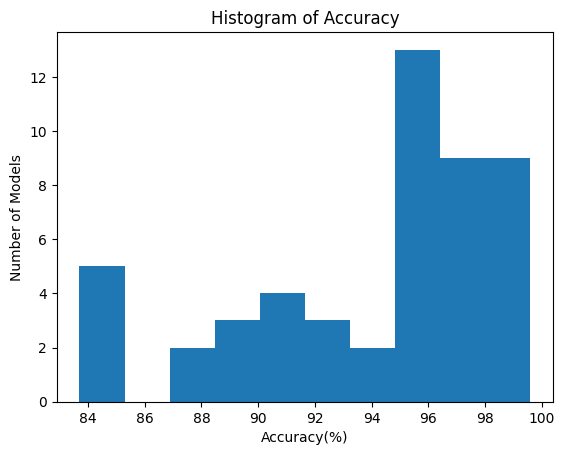

In [85]:
import matplotlib.pyplot as plt

plt.hist(df["Accuracy"])

plt.title("Histogram of Accuracy")
plt.xlabel("Accuracy(%)")
plt.ylabel("Number of Models")

plt.show()

32. Plot a histogram of InferenceLatency.

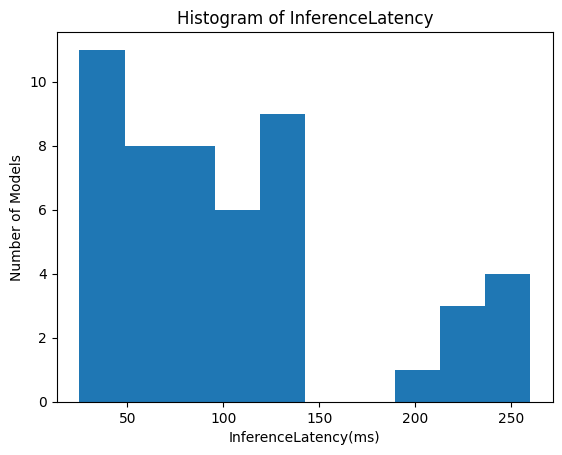

In [86]:
plt.hist(df["InferenceLatency"])

plt.title("Histogram of InferenceLatency")
plt.xlabel("InferenceLatency(ms)")
plt.ylabel("Number of Models")

plt.show()

33. Create a scatter plot of Accuracy vs DataDrift.

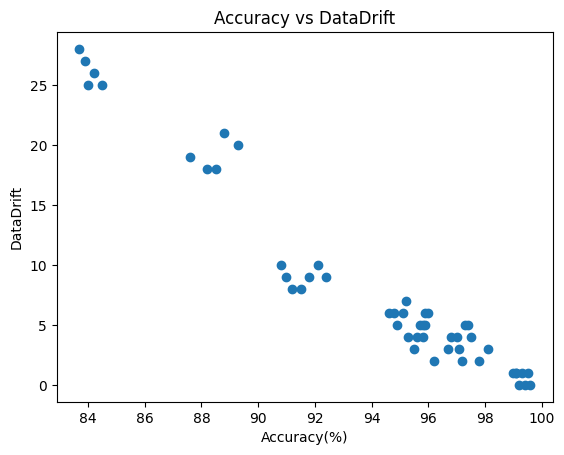

In [87]:
plt.scatter(df["Accuracy"], df["DataDrift"])

plt.title("Accuracy vs DataDrift")
plt.xlabel("Accuracy(%)")
plt.ylabel("DataDrift")

plt.show()

34. Create a scatter plot of CPUUsage vs InferenceLatency.

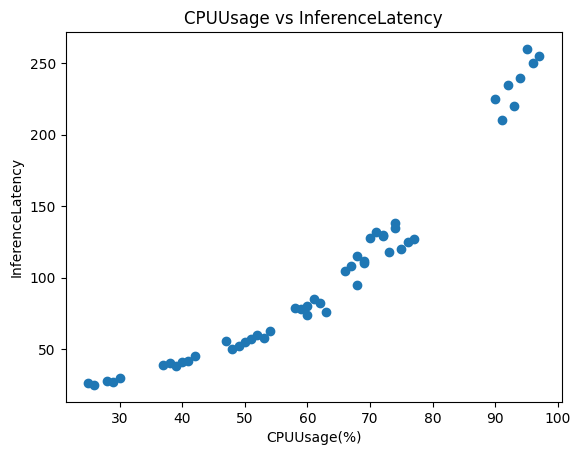

In [88]:
plt.scatter(df["CPUUsage"], df["InferenceLatency"])

plt.title("CPUUsage vs InferenceLatency")
plt.xlabel("CPUUsage(%)")
plt.ylabel("InferenceLatency")

plt.show()

35. Create a bar chart showing the number of models for each algorithm.

Algorithm
CNN             10
RandomForest     9
Transformer      8
XGBoost          7
LSTM             6
SVM              5
DecisionTree     5
Name: count, dtype: int64


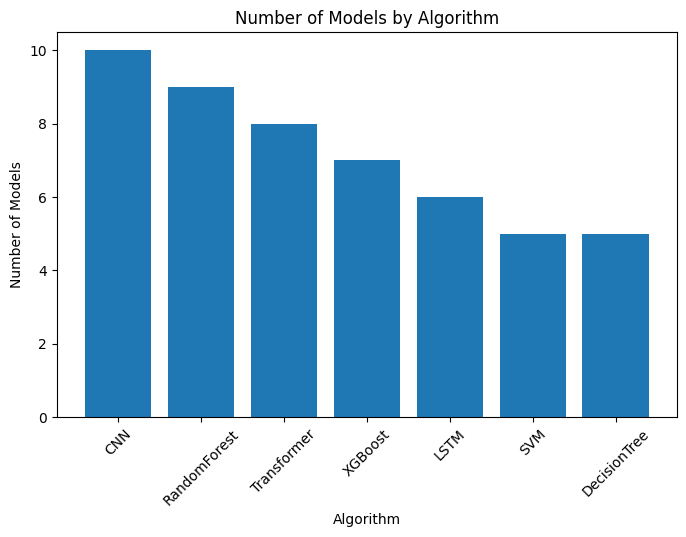

In [89]:
algorithm_counts = df["Algorithm"].value_counts()

print(algorithm_counts)

#Plot the bar chart
import matplotlib.pyplot as plt

algorithm_counts = df["Algorithm"].value_counts()

plt.figure(figsize=(8,5))
plt.bar(algorithm_counts.index, algorithm_counts.values)

plt.title("Number of Models by Algorithm")
plt.xlabel("Algorithm")
plt.ylabel("Number of Models")

plt.xticks(rotation=45)
plt.show()

36. Create a pie chart showing the distribution of FailureRisk.

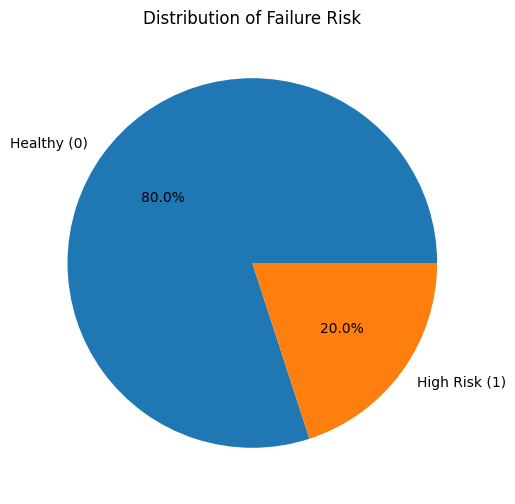

In [90]:
import matplotlib.pyplot as plt

# Count healthy and risky models
failure_counts = df["FailureRisk"].value_counts()

# Create pie chart
plt.figure(figsize=(6,6))

plt.pie(
    failure_counts,
    labels=["Healthy (0)", "High Risk (1)"],
    autopct="%1.1f%%"
)

plt.title("Distribution of Failure Risk")

plt.show()

Part E – Scikit-learn (37–40)


37. Encode the Algorithm column using LabelEncoder.

In [91]:
from sklearn.preprocessing import LabelEncoder

# Create LabelEncoder object
le = LabelEncoder()

# Encode Algorithm column
df["Algorithm_Encoded"] = le.fit_transform(df["Algorithm"])

print(df[["Algorithm", "Algorithm_Encoded"]].head())

      Algorithm  Algorithm_Encoded
0  RandomForest                  3
1       XGBoost                  6
2           CNN                  0
3          LSTM                  2
4           SVM                  4


38. Split the dataset into training and testing sets using an 80:20 ratio.

In [92]:
from sklearn.model_selection import train_test_split

X = df[                                             # x -- > Features, Y --> Targets
    [
        "Algorithm_Encoded",
        "TrainingSamples",
        "Accuracy",
        "InferenceLatency",
        "DataDrift",
        "CPUUsage",
        "PredictionConfidence"
    ]
]

y = df["FailureRisk"]

# Split the Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Set Shape:", X_train.shape)
print("Testing Set Shape :", X_test.shape)

Training Set Shape: (40, 7)
Testing Set Shape : (10, 7)
